In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
master = pd.read_csv("../data/processed/master_dataset.csv")
features = pd.read_csv("../data/processed/feature_table.csv")
ess = pd.read_csv("../data/processed/ess_dataset.csv")

for df in [master, features, ess]:
    df["Date"] = pd.to_datetime(df["Date"])

In [3]:
print("MASTER DATASET")
print("Shape:", master.shape)
print("Date range:", master["Date"].min(), "to", master["Date"].max())

print("\nFEATURE TABLE")
print("Shape:", features.shape)

print("\nESS DATASET")
print("Shape:", ess.shape)

ess.head()

MASTER DATASET
Shape: (1292, 45)
Date range: 1919-01-01 00:00:00 to 2026-08-01 00:00:00

FEATURE TABLE
Shape: (1286, 259)

ESS DATASET
Shape: (1275, 264)


,Date,fred_vix_Value,fred_yield_curve_Value,fred_building_permits_Value,fred_unemployment_rate_Value,fred_consumer_sentiment_Value,fred_industrial_production_Value,fred_federal_funds_rate_Value,fred_cpi_Value,fred_housing_starts_Value,...,trends_inflation_fear_cost of living_pct_change,trends_inflation_fear_cost of living_lag1,trends_inflation_fear_cost of living_rolling3,trends_inflation_fear_cost of living_rolling6,trends_inflation_fear_cost of living_rolling3_std,ESS_macro,ESS_energy,ESS_behavioral,ESS,ESS_target
0,1920-03-01,NaN,NaN,NaN,NaN,NaN,5.5201,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.583180,NaN,NaN,44.168200,54.019058
1,1920-04-01,NaN,NaN,NaN,NaN,NaN,5.2239,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.255340,NaN,NaN,62.553403,49.618937
2,1920-05-01,NaN,NaN,NaN,NaN,NaN,5.3586,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.825040,NaN,NaN,58.250401,52.691496
3,1920-06-01,NaN,NaN,NaN,NaN,NaN,5.4124,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.401906,NaN,NaN,54.019058,59.250901
4,1920-07-01,NaN,NaN,NaN,NaN,NaN,5.2778,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.038106,NaN,NaN,49.618937,60.634018


In [4]:
missing = master.isnull().sum()

missing = missing[missing > 0].sort_values(
    ascending=False
)

missing.head(15)

trends_economic_optimism_luxury watch       1231
trends_economic_optimism_new house          1231
trends_employment_stress_linkedin jobs      1231
trends_employment_stress_resume template    1231
trends_economic_optimism_investment         1231
trends_economic_optimism_startup            1231
trends_economic_optimism_vacation           1231
trends_consumer_caution_budget meals        1231
trends_consumer_caution_thrift store        1231
trends_consumer_caution_used cars           1231
trends_consumer_caution_cheap groceries     1231
trends_consumer_caution_coupon              1231
trends_housing_stress_eviction              1231
trends_housing_stress_affordable housing    1231
trends_financial_anxiety_bankruptcy         1231
dtype: int64

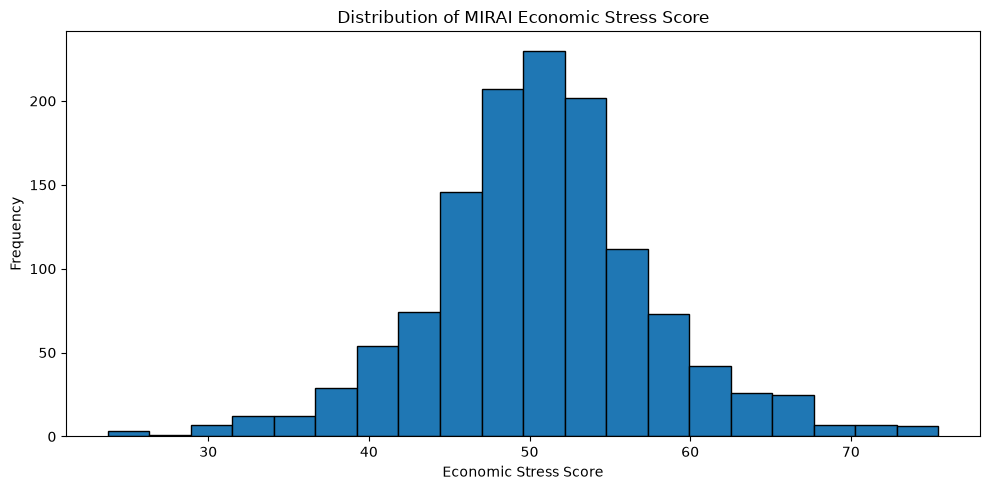

In [5]:
plt.figure(figsize=(10, 5))

plt.hist(
    ess["ESS"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Economic Stress Score")
plt.ylabel("Frequency")
plt.title("Distribution of MIRAI Economic Stress Score")

plt.tight_layout()
plt.show()

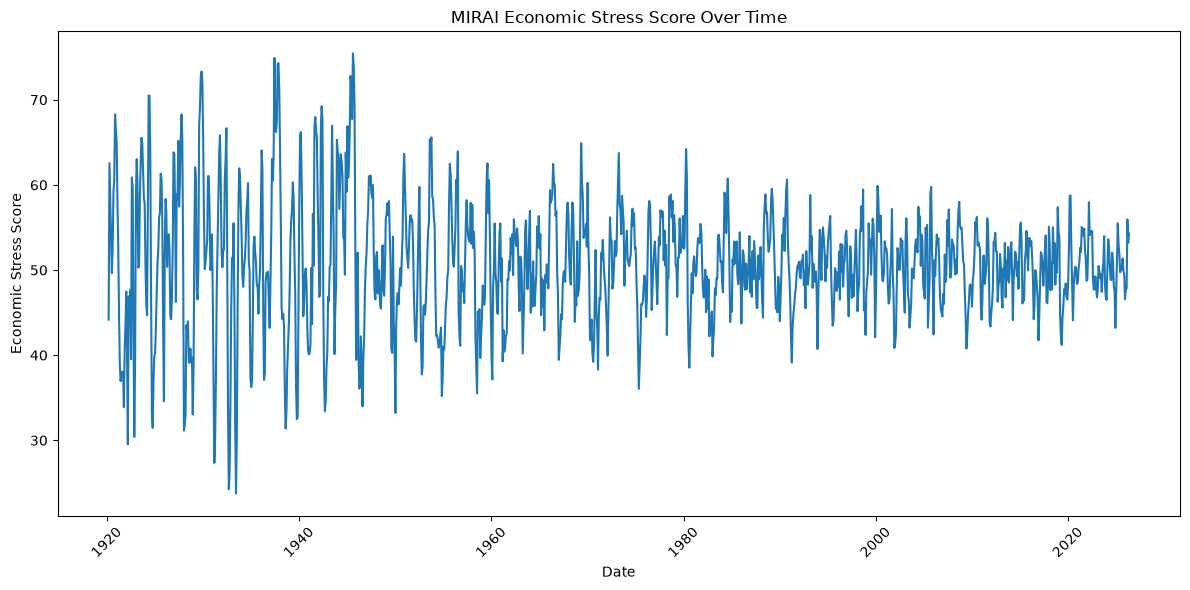

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(
    ess["Date"],
    ess["ESS"]
)

plt.xlabel("Date")
plt.ylabel("Economic Stress Score")
plt.title("MIRAI Economic Stress Score Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

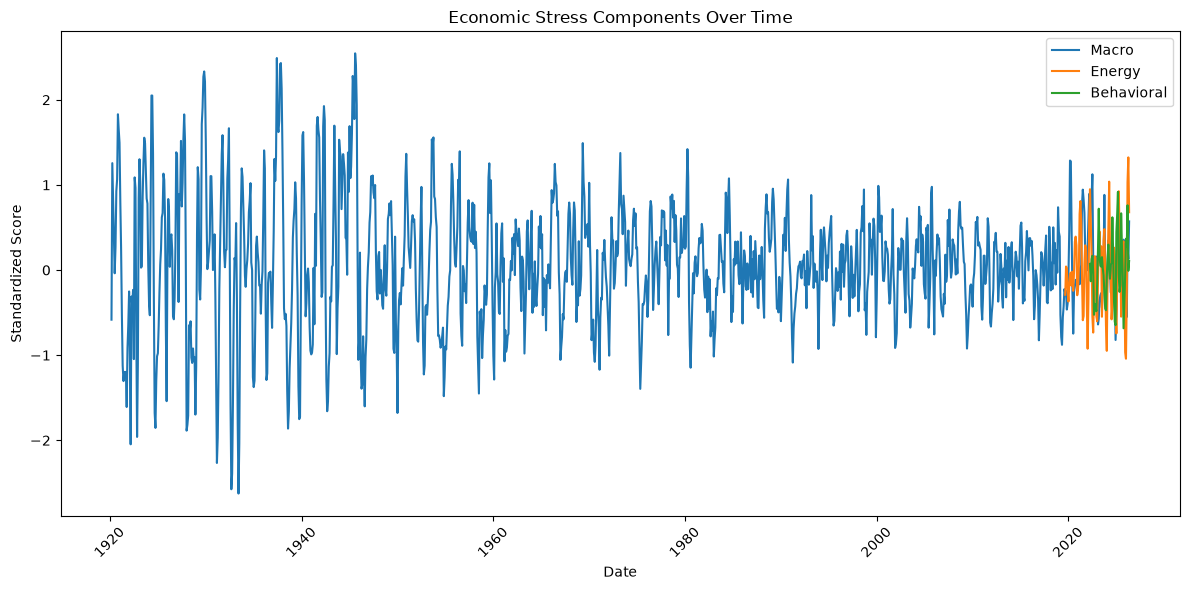

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    ess["Date"],
    ess["ESS_macro"],
    label="Macro"
)

plt.plot(
    ess["Date"],
    ess["ESS_energy"],
    label="Energy"
)

plt.plot(
    ess["Date"],
    ess["ESS_behavioral"],
    label="Behavioral"
)

plt.xlabel("Date")
plt.ylabel("Standardized Score")
plt.title("Economic Stress Components Over Time")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
ess[[
    "ESS_macro",
    "ESS_energy",
    "ESS_behavioral",
    "ESS"
]].describe()

,ESS_macro,ESS_energy,ESS_behavioral,ESS
count,1275.000000,81.000000,50.000000,1275.000000
mean,0.073405,0.009395,0.014962,50.720552
std,0.712915,0.498268,0.378760,7.082537
min,-2.625618,-1.041856,-0.684260,23.743821
25%,-0.327012,-0.311587,-0.236560,46.812938
50%,0.056420,-0.017517,0.016543,50.562778
75%,0.454987,0.309624,0.172849,54.466790
max,2.545331,1.323201,0.917809,75.453313
